# Friedman's H-statistic Example
This is demo of [Friedman's H-statistic](https://christophm.github.io/interpretable-ml-book/interaction.html).

# Virtual Environment and Dependencies
Prepare and activate virtual environment with MLI-2 dependencies. Import dependencies:

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from mli.explanation.h_statistic import HStatistic

## Dataset
Simple dataset with numerical and categorical features:

In [2]:
X = pd.DataFrame({
            'a': [9, 8, 7, 6, 5],
            'F': [3, 4, 5, 4, 3],
            'G': [10, 20, 30, 40, 50],
            'H': [.1, .2, .3, .4, .5],
            'b': [5, 6, 7, 8, 9]})

print(X)

   a  F   G    H  b
0  9  3  10  0.1  5
1  8  4  20  0.2  6
2  7  5  30  0.3  7
3  6  4  40  0.4  8
4  5  3  50  0.5  9


## Examples
Foo predict methods for regression without any dependencies just for demonstration purposes - note method signature with exactly one input parameter (dataset) and Pandas DataFrame return value with 1 column:

In [3]:
def predict(x):
    return (x['a'] + x['F'] + x['G'] * x['H'] - x['b']) ** (1 / 2)

Calculate **H-statistic** for pairs of given features:

In [4]:
features = ['a', 'F', 'G', 'H']
bins = [[6, 8], [3, 5], [20, 40], [.1, .4]]
h_statistic = HStatistic("H-stat for pairs").explain(
            features,
            X,
            predict_method=predict,
            bins=bins)

print("H-statistic for {}:\n{}".format(features, h_statistic))

H-statistic for ['a', 'F', 'G', 'H']:

'('a', 'F')':
  'p_0':
    0.0019243657443162733
'('a', 'G')':
  'p_0':
    0.001532921265007652
'('a', 'H')':
  'p_0':
    0.0034120589987928786
'('F', 'G')':
  'p_0':
    0.0015442776397910224
'('F', 'H')':
  'p_0':
    0.003419540968816887
'('G', 'H')':
  'p_0':
    0.03775762935652526



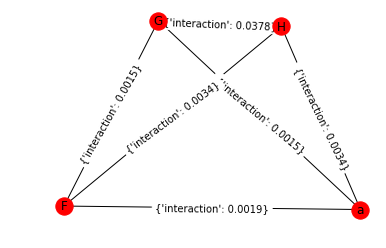

In [8]:
import networkx as nx
G = nx.Graph()
G.add_nodes_from(features)
exs = h_statistic.explanations()
for i in exs:
    G.add_edge(i[0], i[1], interaction=float("%0.4f"%exs[i]['p_0']))
pos = nx.spring_layout(G, weight='interaction')
nx.draw_networkx_edge_labels(G, pos)
nx.draw_networkx_labels(G, pos, with_labels=True)
nx.draw(G, pos)